# Bank Marketing Classification

---

Author: heleneInsights

---

## Objective
This project applies data cleaning, exploratory data analysis, and machine learning models to predict whether a client will subscribe to a term deposit based on the **Bank Marketing Dataset** from the UCI Machine Learning Repository.

---

## Problem Statement
The goal is to build a classification model that predicts the variable **`y`** (whether a client subscribes to a term deposit) using demographic, financial, and campaign-related features.

# Dataset Description

This dataset contains information from direct phone marketing campaigns run by a Portuguese bank. Each record represents a client contact, often with multiple calls per client. The goal is to predict whether a client will subscribe to a term deposit (“yes” or “no”) based on their characteristics and campaign interactions.

## Dataset Information

* **Number of observations**: 4,119 client records
* **Number of features**: 17 input variables + 1 target variable
* **Target variable**: `y` (term deposit subscription: yes/no)

## Data Dictionary — Bank Marketing Dataset

| Column         | Type  | Description                           | Example             |
| -------------- | ----- | ------------------------------------- | ------------------- |
| age            | int   | Age of the client                     | 39                  |
| job            | str   | Type of job                           | "admin."            |
| marital        | str   | Marital status                        | "married"           |
| education      | str   | Education level                       | "university.degree" |
| default        | str   | Has credit in default?                | "no"                |
| housing        | str   | Has housing loan?                     | "yes"               |
| loan           | str   | Has personal loan?                    | "no"                |
| contact        | str   | Contact communication type            | "cellular"          |
| month          | str   | Last contact month                    | "may"               |
| day_of_week    | str   | Last contact day                      | "fri"               |
| duration       | int   | Last call duration (seconds)          | 487                 |
| campaign       | int   | Number of contacts during campaign    | 2                   |
| pdays          | int   | Days since last contact (999 = never) | 999                 |
| previous       | int   | Previous campaign contacts            | 0                   |
| poutcome       | str   | Previous campaign outcome             | "nonexistent"       |
| euribor3m      | float | Euribor 3-month rate                  | 1.313               |
| previously_contacted      | int | Has been previously contacted?                  | 0               |
| y              | str   | Target: subscribed term deposit?      | "no"                |

For further information regarding the dataset exploration and the rationale behind the preprocessing choices, please refer to `01_eda.ipynb`.

---

# Data Loading and Inspection
## Import Libraries

In [ ]:
# Standard library imports
from pathlib import Path
import warnings
import time

# Third-party imports
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split,
    learning_curve
) 
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import joblib
from lazypredict.Supervised import LazyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score

### Dataset Availability and Path Setup

In [2]:
data_dir = Path("../data/processed/")

# List available files (for verification)
available_files = list(data_dir.iterdir())
print("Available files:", available_files)
file_name = "bank_additional_clean.csv"
dataset_path = data_dir / file_name

Available files: [WindowsPath('../data/processed/bank_additional_clean.csv')]


In [3]:
# Validate dataset existence
if not dataset_path.exists():
    raise FileNotFoundError(f"{file_name} not found in {data_dir}")

print("Dataset found at:", dataset_path)

Dataset found at: ..\data\processed\bank_additional_clean.csv


## Load Dataset

In [4]:
df = pd.read_csv(dataset_path)

### Display Configuration

To prevent pandas from truncating large outputs during data exploration, the following display settings were applied:

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

This allows all rows and columns to be displayed when inspecting DataFrames.

### Verify Data Load

The dataset has been successfully loaded and validated. It contains a combination of demographic, financial, and campaign-related features used to predict term deposit subscription outcomes.

For a detailed breakdown of the dataset structure, feature distributions, and exploratory data analysis insights, refer to `01_eda.ipynb`.

For information on data cleaning procedures, preprocessing steps, and feature engineering, refer to `02_preprocessing.ipynb`.

Below is a preview of the processed dataset:

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,euribor3m,y,previously_contacted
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,0,0,nonexistent,1.313,no,0
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,0,0,nonexistent,4.855,no,0
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,0,0,nonexistent,4.962,no,0
3,38,services,married,basic.9y,no,yes,no,telephone,jun,fri,17,3,0,0,nonexistent,4.959,no,0
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,0,0,nonexistent,4.191,no,0


### Verify Structure

The dataset `bank_additional_clean.csv` was successfully loaded and its structure was verified.

In [7]:
print(f"{file_name}")
print(f"Shape: {df.shape}")
print(f"→ {df.shape[0]} rows, {df.shape[1]} columns\n")

bank_additional_clean.csv
Shape: (4119, 18)
→ 4119 rows, 18 columns



### Inspect Data Types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   4119 non-null   int64  
 1   job                   4119 non-null   str    
 2   marital               4119 non-null   str    
 3   education             4119 non-null   str    
 4   default               4119 non-null   str    
 5   housing               4119 non-null   str    
 6   loan                  4119 non-null   str    
 7   contact               4119 non-null   str    
 8   month                 4119 non-null   str    
 9   day_of_week           4119 non-null   str    
 10  duration              4119 non-null   int64  
 11  campaign              4119 non-null   int64  
 12  pdays                 4119 non-null   int64  
 13  previous              4119 non-null   int64  
 14  poutcome              4119 non-null   str    
 15  euribor3m             4119 non-n

The dataset consists of 4,119 records and 18 columns. All features are fully populated with no missing values.

The dataset includes a mix of numerical and categorical variables, with categorical features stored as strings and numerical features in integer or float format.

Target variable: `y` (binary classification: term deposit subscription)

#### Feature Composition

* **Numerical features:** 7 (`age`, `duration`, `campaign`, `pdays`, `previous`, `euribor3m`, `previously_contacted`)
* **Categorical features:** 11 (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`, `y`)
* **Memory usage:** ~579 KB

---

## Train-Test Split

Before training the model, the dataset is divided into features (`X`) and target (`y`).

The target variable is `y`, while the remaining columns are used as predictive features. Columns previously identified as redundant or non-informative for modeling are removed from the dataset.

The data is then split into training and testing subsets using an 70/30 ratio:

- **70%** of the data is used to train the model
- **30%** is reserved for evaluating model performance on unseen data

A fixed `random_state` is used to ensure reproducibility of the results. 

Additionally, **stratified sampling** is recommended to preserve the original class distribution of `y` in both the training and testing sets.

This split ensures unbiased evaluation of model generalization performance on unseen data.

In [11]:
# =========================
# Prepare Modeling Dataset
# =========================

df_model = df.copy()

# Target
target = "y"
# Binary classification mapping
target_map = {
    "no": 0,
    "yes": 1
}

# Features and target
X = df_model.drop(columns=[target])
y = df_model[target].map(target_map)

# =========================
# Train-Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [12]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape: (2883, 17)
X_test shape : (1236, 17)
y_train shape: (2883,)
y_test shape : (1236,)


### Shape check

* Train: (2883, 17)
* Test: (1236, 17)

- Consistent feature space
- No leakage
- Correct 70/30 split behavior

In [13]:
print("Overall")
print(y.value_counts(normalize=True))

print("\nTrain")
print(y_train.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

Overall
y
0    0.890507
1    0.109493
Name: proportion, dtype: float64

Train
y
0    0.890392
1    0.109608
Name: proportion, dtype: float64

Test
y
0    0.890777
1    0.109223
Name: proportion, dtype: float64


### Stratification Check

#### Overall distribution

* Class 0: 89.05%
* Class 1: 10.95%

#### Training set

* Class 0: 89.04%
* Class 1: 10.96%

#### Test set

* Class 0: 89.08%
* Class 1: 10.92%

The stratified split preserves the original class distribution across both training and test sets with high fidelity.

* Train and test distributions closely match the full dataset
* No sampling distortion is introduced
* Class imbalance (~89/11) is maintained consistently

This confirms that stratification was applied correctly and the dataset is suitable for unbiased model evaluation.

---

# Pipeline Preparation
This section defines the final preprocessing pipeline and integrates it into a baseline machine learning model. The preprocessing steps were saved to ensure consistent transformations across all benchmarking models.

In [9]:
preprocessor = joblib.load("../models/preprocessor.joblib")

# Baseline Model Pipeline (Decision Tree)

The previously saved preprocessing pipeline is loaded to ensure consistent feature transformations across all experiments.

A baseline model is then constructed using a **Decision Tree classifier**, integrated into a unified sklearn pipeline. This ensures that preprocessing and model training are executed in a single, reproducible workflow.

This baseline serves as a reference point for evaluating more advanced models in subsequent stages.

In [14]:
# Build baseline model pipeline (Decision Tree)
dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Model Training

The pipeline is trained using the training dataset, which automatically applies all preprocessing steps before fitting the model.

During this process, the pipeline:

1. Imputes missing values (if any)
2. Scales numerical features
3. Encodes ordinal categorical variables
4. One-hot encodes nominal categorical variables
5. Fits the model using the transformed data

Because preprocessing and modeling are encapsulated within the same pipeline, future predictions will automatically receive the exact same transformations that were applied during training. This ensures consistency between training and inference and helps prevent data leakage.

In [15]:
# =========================
# Fit Model
# =========================
dt.fit(X_train, y_train)
dt

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('minmax_num', ...), ('standard_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [16]:
# =========================
# Pipeline Ready
# =========================
print("Pipeline successfully trained.")

Pipeline successfully trained.


---

## Model Performance Evaluation

To assess the model's ability to generalize to unseen data, performance metrics were calculated for both the training and testing datasets.

Comparing these results helps identify potential overfitting or underfitting. A model that generalizes well should achieve similar performance on both datasets, indicating that it has learned meaningful patterns rather than memorizing the training observations.

In [18]:
# =========================
# Predictions
# =========================

warnings.filterwarnings("ignore", message="X does not have valid feature names")

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)


# =========================
# Performance Summary
# =========================

performance_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    "F1 (Weighted)": [
        f1_score(y_train, y_train_pred, average="weighted"),
        f1_score(y_test, y_test_pred, average="weighted")
    ],
    "F1 (Macro)": [
        f1_score(y_train, y_train_pred, average="macro"),
        f1_score(y_test, y_test_pred, average="macro")
    ]
})

performance_df["F1 Gap"] = (
    performance_df.loc[0, "F1 (Macro)"] - performance_df.loc[1, "F1 (Macro)"]
)

display(performance_df.round(4))

,Dataset,Accuracy,F1 (Weighted),F1 (Macro),F1 Gap
0,Train,1.0000,1.0000,1.0000,0.2892
1,Test,0.8867,0.8871,0.7108,0.2892


## Model Performance Summary

| Dataset | Accuracy | F1 (Weighted) | F1 (Macro) | F1 Gap |
| ------- | -------- | ------------- | ---------- | ------ |
| Train   | 1.0000   | 1.0000        | 1.0000     | 0.2892 |
| Test    | 0.8867   | 0.8871        | 0.7108     | 0.2892 |

The model achieves perfect performance on the training set but significantly lower performance on the test set.

* The **perfect training scores (1.0 across all metrics)** indicate the model has fully memorized the training data.
* The drop in test performance, especially in **F1 (macro)**, confirms a clear generalization gap.
* The consistent **F1 gap (0.2892)** highlights strong overfitting behavior.

### Key Insight

Despite relatively high test accuracy, the imbalance-sensitive metric (macro F1) reveals that the model struggles to generalize across classes. This suggests the model is biased toward the majority class and is not robust for minority class detection.

### Practical takeaway

This baseline model is **not suitable for deployment** without regularization or model adjustment. The next iteration should focus on reducing overfitting through:

* pruning / depth control (if tree-based)
* regularization (if linear models)
* or switching to ensemble methods (Random Forest, Gradient Boosting)

### Classification Report Analysis

In [19]:
class_names = ["No Subscription (0)", "Yes Subscription (1)"]

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names
    )
)

                      precision    recall  f1-score   support

 No Subscription (0)       0.94      0.94      0.94      1101
Yes Subscription (1)       0.48      0.49      0.49       135

            accuracy                           0.89      1236
           macro avg       0.71      0.71      0.71      1236
        weighted avg       0.89      0.89      0.89      1236



#### Overall performance

* **Accuracy:** 0.89 (looks strong, but misleading due to imbalance)
* **Macro F1:** 0.71 → better indicator of true performance across classes

#### Class-wise performance

##### No Subscription (0) — Majority class

* Precision: 0.94
* Recall: 0.94
* F1-score: 0.94

- The model performs very well here
- It correctly identifies most non-subscribers
- This drives the high accuracy score

##### Yes Subscription (1) — Minority class (important one)

* Precision: 0.48
* Recall: 0.49
* F1-score: 0.49

This is the real problem area:

* The model correctly identifies only ~49% of actual subscribers
* About half of potential customers are being missed
* Precision is also low → many false positives

#### Key Insight

Even though overall accuracy is high, the model is **biased toward the majority class (0)** and struggles to reliably detect the minority class (1), which is typically the **business-critical segment** in marketing prediction problems.

#### What this means in practice

If this model were used in a campaign:

* Many non-interested customers would still be targeted (false positives)
* A large portion of actual interested customers would be missed (false negatives)

#### Bottom line

* Good overall classification signal
* Strong imbalance effect
* Weak minority-class detection
* Model is **not yet suitable for business deployment**

#### Next step (optional, to improve the model)

To fix this, we should move toward:

* class weighting (`class_weight="balanced"`)
* threshold tuning (very important here)
* or switching to ensemble models (Random Forest / Gradient Boosting)
* optionally SMOTE (if appropriate in your pipeline design)

### Confusion Matrix

In [20]:
# Predictions
y_pred = dt.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print as table
class_names = ["No Subscription (0)", "Yes Subscription (1)"]

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {c}' for c in class_names],
    columns=[f'Predicted {c}' for c in class_names]
)

cm_df

,Predicted No Subscription (0),Predicted Yes Subscription (1)
Actual No Subscription (0),1030,71
Actual Yes Subscription (1),69,66


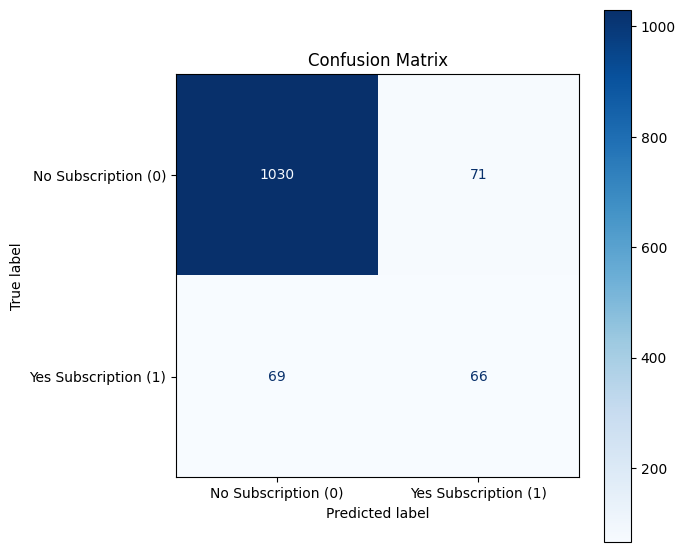

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test,
    y_test,
    display_labels=class_names,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#### Confusion Matrix Interpretation

##### 1. Correct predictions

* **True Negatives (TN): 1030**
* **True Positives (TP): 66**

So the model is generally strong at identifying non-subscribers and moderately successful at finding subscribers.

##### 2. Errors that matter

##### False Negatives (69)

* Actual subscribers predicted as non-subscribers
* This is the **most costly error in our business context**
* We are missing ~**51% of all actual subscribers (69 out of 135)**

##### False Positives (71)

* Non-subscribers incorrectly targeted
* These increase campaign cost but are usually less damaging than FN in marketing problems

#### Key insight

The model is **conservative in predicting “Yes” (1)**:

* It avoids false positives fairly well
* But it sacrifices recall for class 1

This matches our earlier classification report:

* Class 1 recall ≈ 0.49

#### Business interpretation

If this model is used in a campaign:

* We correctly capture ~49% of potential customers
* We miss ~51% of interested customers
* We waste some budget targeting ~71 non-interested clients per 1236

So the model is:

* Reasonable baseline
* Not optimized for marketing recall

#### What this tells us about model behavior

This is typical of:

* default decision trees
* imbalanced datasets (~89/11 split)
* no class weighting or threshold tuning

#### Next improvement direction

To improve recall for class 1:

1. `class_weight="balanced"`
2. adjust decision threshold (not 0.5)
3. try ensemble models:

   * Random Forest
   * Gradient Boosting (very strong here)
4. optionally optimize for **recall or F2-score** instead of accuracy

# Benchmarking

## LazyClassifier

To benchmark model performance, we evaluate a wide range of classification algorithms using `LazyClassifier`. All models are trained and tested on the same preprocessed feature set to ensure a fair and consistent comparison.

This allows us to quickly identify strong candidate models and assess whether more complex approaches provide meaningful performance improvements over simpler baselines.

We apply `LazyClassifier` on the fully preprocessed dataset to ensure compatibility across all models, as the framework requires purely numeric input.

In [24]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [25]:
print(X_train_prepared.shape)
print(X_test_prepared.shape)

(2883, 29)
(1236, 29)


In [28]:
clfs = LazyClassifier(
    verbose=0,
    ignore_warnings=True
)

lazy_results, lazy_predictions = clfs.fit(
    X_train_prepared,
    X_test_prepared,
    y_train,
    y_test
)

lazy_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
BaggingClassifier,0.902913,0.705036,0.882743,0.897906,0.894658,0.902913,0.065042
XGBClassifier,0.901294,0.713876,0.921741,0.897790,0.895143,0.901294,0.209457
LGBMClassifier,0.898058,0.702311,0.925280,0.894041,0.891040,0.898058,0.113670
AdaBoostClassifier,0.908576,0.649722,0.924799,0.893695,0.894237,0.908576,0.093626
LinearDiscriminantAnalysis,0.899676,0.657725,0.916729,0.888868,0.884640,0.899676,0.027231
CalibratedClassifierCV,0.902913,0.630296,0.916016,0.886163,0.885281,0.902913,0.059131
RandomForestClassifier,0.898867,0.644273,0.919723,0.886047,0.881926,0.898867,0.178992
DecisionTreeClassifier,0.885113,0.708043,0.708043,0.885483,0.885861,0.885113,0.018285
LinearSVC,0.903722,0.621001,0.915848,0.884799,0.886208,0.903722,0.014039


## Benchmark Results Summary (LazyClassifier)

We now prioritize **F1-score performance**, since it balances precision and recall and is more sensitive to minority class performance than accuracy.

### Best models by F1-score

Top performers:

* **BaggingClassifier**

  * F1: **0.898 (highest overall)**
  * Strong and stable baseline ensemble

* **XGBClassifier**

  * F1: **0.898**
  * Better ranking behavior (ROC AUC 0.922)
  * Strong candidate for tuning

* **LGBMClassifier**

  * F1: **0.894**
  * Very close to top
  * Best ROC AUC (0.925 → strong separation ability)

### Key insight

Even though multiple models have similar F1 (~0.89), we already saw:

* Class 0 is dominating performance
* Class 1 recall is the real weakness (~0.49 earlier)

So **global F1 is not enough alone**
We need to **shift focus toward class 1 F1 / recall explicitly**

### What this means for model selection

We should prioritize models that:

### Handle imbalance better

* XGBClassifier
* LGBMClassifier

### Recommended direction (based on F1 + class 1 goal)

### Primary candidates:

* **XGBClassifier (preferred)**
* **LGBMClassifier**

Why:

* strong F1
* strong ROC AUC (ranking ability helps threshold tuning)
* flexible for class weighting

### Next step

To improve **class 1 recall**, we don’t change models first — we change *decision behavior*:

We will focus on:

#### 1. Threshold tuning (critical)

Instead of 0.5 → optimize for:

* max F1 (class 1)
* or recall constraint

#### 2. Class weighting

* `scale_pos_weight` (XGBoost / LightGBM)
* `class_weight='balanced'` (sklearn models)

#### 3. Metric shift during training

Optimize for:

* F1 (macro or class 1)
  not accuracy

### Bottom line

We are no longer selecting “best model overall.”

We are selecting:

the model that gives the best **class 1 detection performance under F1 optimization**

And right now:
XGBoost / LightGBM are the strongest starting points.

## Selected Models to Compare

Based on the LazyClassifier benchmark results, we select a subset of models for deeper comparison. The selection includes the top-performing algorithms as well as representative baseline models to provide a balanced evaluation.

The models considered in this comparison are:

* Decision Tree Classifier (baseline model)
* Support Vector Machine (SVM)
* XGBoost Classifier
* LightGBM Classifier
* Bagging Classifier

These models were chosen based on their performance across key metrics such as F1-score and ROC AUC, as well as their relevance for binary classification tasks with imbalanced data.

In [44]:
benchmark_models = {
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LGBMClassifier": LGBMClassifier(random_state=42),
    "BaggingClassifier": BaggingClassifier(random_state=42)
}

## Optimizing Selected Models

**Shared CV strategy**

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### DecisionTreeClassifier Optuna optimization

In [66]:
def objective_dt(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "class_weight": "balanced",
        "random_state": 42
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(**params))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

#### Run optimization

In [67]:
study_dt = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_dt.optimize(objective_dt, n_trials=30)

print(study_dt.best_params)
print(study_dt.best_value)

[I 2026-06-18 11:18:38,115] A new study created in memory with name: no-name-34e2ba7d-85ab-4cbc-950b-0890f4c3bf7d
[I 2026-06-18 11:18:38,175] Trial 0 finished with value: 0.7171710934118277 and parameters: {'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 15, 'criterion': 'gini'}. Best is trial 0 with value: 0.7171710934118277.
[I 2026-06-18 11:18:38,223] Trial 1 finished with value: 0.7115964074491377 and parameters: {'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 18, 'criterion': 'entropy'}. Best is trial 0 with value: 0.7171710934118277.
[I 2026-06-18 11:18:38,271] Trial 2 finished with value: 0.5814533503967965 and parameters: {'max_depth': 2, 'min_samples_split': 20, 'min_samples_leaf': 17, 'criterion': 'gini'}. Best is trial 0 with value: 0.7171710934118277.
[I 2026-06-18 11:18:38,319] Trial 3 finished with value: 0.7188322029513639 and parameters: {'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 11, 'criterion': 'gini'}. Best is trial 3 with 

{'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'criterion': 'entropy'}
0.7371056475770091


#### Best Decision Tree Result
```python
best_params = {
    'max_depth': 20,
    'min_samples_split': 15,
    'min_samples_leaf': 6,
    'criterion': 'entropy'
}
best_score = 0.7371
```

#### Update `benchmark_models`

In [68]:
benchmark_models["DecisionTreeClassifier"] = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=15,
    min_samples_leaf=6,
    criterion="entropy",
    class_weight="balanced",
    random_state=42
)

### SVC Optuna optimization

In [48]:
def objective_svc(trial):
    params = {
        "C": trial.suggest_float("C", 0.1, 10.0, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "poly"]),
        "gamma": trial.suggest_float("gamma", 1e-4, 1.0, log=True),
        "class_weight": "balanced",
        "probability": True
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", SVC(**params))
    ])

    score = cross_val_score(
        model, X_train, y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

#### Run optimization

In [49]:
study_svc = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_svc.optimize(objective_svc, n_trials=30)

print(study_svc.best_params)
print(study_svc.best_value)

[I 2026-06-18 10:56:15,416] A new study created in memory with name: no-name-85ddc1a4-ec49-4e0f-8b55-cb922156badb
[I 2026-06-18 10:56:17,261] Trial 0 finished with value: 0.7335695891148009 and parameters: {'C': 0.5611516415334505, 'kernel': 'rbf', 'gamma': 0.024810409748678097}. Best is trial 0 with value: 0.7335695891148009.
[I 2026-06-18 10:56:19,109] Trial 1 finished with value: 0.7056719162042214 and parameters: {'C': 0.20513382630874505, 'kernel': 'rbf', 'gamma': 0.29154431891537513}. Best is trial 0 with value: 0.7335695891148009.
[I 2026-06-18 10:56:21,244] Trial 2 finished with value: 0.4888571872413922 and parameters: {'C': 1.5930522616241019, 'kernel': 'rbf', 'gamma': 0.7579479953348001}. Best is trial 0 with value: 0.7335695891148009.
[I 2026-06-18 10:56:22,915] Trial 3 finished with value: 0.7406254950198827 and parameters: {'C': 4.622589001020832, 'kernel': 'rbf', 'gamma': 0.0005415244119402539}. Best is trial 3 with value: 0.7406254950198827.
[I 2026-06-18 10:56:24,019] 

{'C': 0.2592187764570012, 'kernel': 'rbf', 'gamma': 0.0018735202467041055}
0.7503923520588894


#### Best SVC result (from Optuna)
```python
best_params = {
    "C": 0.2592,
    "kernel": "rbf",
    "gamma": 0.00187
}

best_score = 0.7504  # F1_macro
```

#### Add optimized SVC to `benchmark_models`

In [50]:
benchmark_models["SVC"] = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        C=0.2592187764570012,
        kernel="rbf",
        gamma=0.0018735202467041055,
        probability=True
    ))
])

### XGBoost Optuna optimization

In [52]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(**params))
    ])

    score = cross_val_score(
        model, X_train, y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

#### Run optimization

In [53]:
study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=30)

print(study_xgb.best_params)
print(study_xgb.best_value)

[I 2026-06-18 11:04:29,093] A new study created in memory with name: no-name-5e4efc0e-9f05-43df-a4e0-420d8d7e8bf1
[I 2026-06-18 11:04:31,196] Trial 0 finished with value: 0.7827949548030787 and parameters: {'n_estimators': 287, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_lambda': 0.0017073967431528124, 'scale_pos_weight': 8.795585311974417}. Best is trial 0 with value: 0.7827949548030787.
[I 2026-06-18 11:04:32,973] Trial 1 finished with value: 0.7710467834876343 and parameters: {'n_estimators': 401, 'max_depth': 8, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808, 'reg_lambda': 0.005337032762603957, 'scale_pos_weight': 2.650640588680904}. Best is trial 0 with value: 0.7827949548030787.
[I 2026-06-18 11:04:34,631] Trial 2 finished with value: 0.7754648819201501 and parameters: {'n_

{'n_estimators': 252, 'max_depth': 4, 'learning_rate': 0.020319346889135673, 'subsample': 0.7549879999732994, 'colsample_bytree': 0.7912108321984976, 'gamma': 4.0985070414347, 'reg_lambda': 0.04766916451540558, 'scale_pos_weight': 3.3285076952371617}
0.7928108145185283


#### Best XGBoost result (from Optuna)
```python
best_params = {
    "n_estimators": 252,
    "max_depth": 4,
    "learning_rate": 0.020319346889135673,
    "subsample": 0.7549879999732994,
    "colsample_bytree": 0.7912108321984976,
    "gamma": 4.0985070414347,
    "reg_lambda": 0.04766916451540558,
    "scale_pos_weight": 3.3285076952371617
}

best_score = 0.7928
```

#### Add optimized XGBoost to `benchmark_models`

In [54]:
benchmark_models["XGBClassifier"] = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=252,
        max_depth=4,
        learning_rate=0.020319346889135673,
        subsample=0.7549879999732994,
        colsample_bytree=0.7912108321984976,
        gamma=4.0985070414347,
        reg_lambda=0.04766916451540558,
        scale_pos_weight=3.3285076952371617,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

### LightGBM Optuna optimization

In [56]:
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "class_weight": "balanced",
        "random_state": 42
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(**params))
    ])

    score = cross_val_score(
        model, X_train, y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

#### Run optimization

In [57]:
study_lgbm = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=30)

print(study_lgbm.best_params)
print(study_lgbm.best_value)

[I 2026-06-18 11:09:00,181] A new study created in memory with name: no-name-d69d8a13-1bcc-403c-830c-5c09c4380c42
[I 2026-06-18 11:09:03,330] Trial 0 finished with value: 0.7667584526508703 and parameters: {'n_estimators': 287, 'num_leaves': 144, 'max_depth': 10, 'learning_rate': 0.07661100707771368, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 0.7667584526508703.
[I 2026-06-18 11:09:05,527] Trial 1 finished with value: 0.7662043423231799 and parameters: {'n_estimators': 401, 'num_leaves': 112, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 0 with value: 0.7667584526508703.
[I 2026-06-18 11:09:07,800] Trial 2 finished with value: 0.7710972180357258 and parameters: {'n_estimators': 252, 'num_leaves': 8

{'n_estimators': 108, 'num_leaves': 136, 'max_depth': 12, 'learning_rate': 0.09807760376191979, 'subsample': 0.6090386847151308, 'colsample_bytree': 0.7146956200280333, 'reg_alpha': 0.4479717901387348, 'reg_lambda': 0.06326694228185313}
0.7804295044016138


#### Best LightGBM result (from Optuna)
```python
best_params = {
    "n_estimators": 108,
    "num_leaves": 136,
    "max_depth": 12,
    "learning_rate": 0.09807760376191979,
    "subsample": 0.6090386847151308,
    "colsample_bytree": 0.7146956200280333,
    "reg_alpha": 0.4479717901387348,
    "reg_lambda": 0.06326694228185313
}

best_score = 0.7804
```

#### Add optimized LightGBM to `benchmark_models`

In [58]:
benchmark_models["LGBMClassifier"] = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=108,
        num_leaves=136,
        max_depth=12,
        learning_rate=0.09807760376191979,
        subsample=0.6090386847151308,
        colsample_bytree=0.7146956200280333,
        reg_alpha=0.4479717901387348,
        reg_lambda=0.06326694228185313,
        random_state=42
    ))
])

### BaggingClassifier Optuna optimization

In [62]:
def objective_bagging(trial):
    tree_params = {
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "class_weight": "balanced",
        "random_state": 42
    }

    base_estimator = DecisionTreeClassifier(**tree_params)

    bag_params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        "max_features": trial.suggest_float("max_features", 0.5, 1.0),
        "bootstrap": True,
        "random_state": 42
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", BaggingClassifier(
            estimator=base_estimator,
            **bag_params
        ))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

#### Run optimization

In [63]:
study_bagging = optuna.create_study(direction="maximize")
study_bagging.optimize(objective_bagging, n_trials=30)

print(study_bagging.best_params)
print(study_bagging.best_value)

[I 2026-06-18 11:15:01,795] A new study created in memory with name: no-name-66024ebf-39e6-4103-93b2-55f5980f4c45
[I 2026-06-18 11:15:02,547] Trial 0 finished with value: 0.7594839934012707 and parameters: {'max_depth': 8, 'min_samples_split': 15, 'min_samples_leaf': 15, 'n_estimators': 87, 'max_samples': 0.601915420018585, 'max_features': 0.9291562222580854}. Best is trial 0 with value: 0.7594839934012707.
[I 2026-06-18 11:15:04,501] Trial 1 finished with value: 0.768889375977763 and parameters: {'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 14, 'n_estimators': 277, 'max_samples': 0.9722807169843535, 'max_features': 0.5409534172112132}. Best is trial 1 with value: 0.768889375977763.
[I 2026-06-18 11:15:06,319] Trial 2 finished with value: 0.7630233704647615 and parameters: {'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 18, 'n_estimators': 251, 'max_samples': 0.6477318411727677, 'max_features': 0.8722773340362444}. Best is trial 1 with value: 0.76888937597

{'max_depth': 8, 'min_samples_split': 19, 'min_samples_leaf': 2, 'n_estimators': 51, 'max_samples': 0.6384569381383332, 'max_features': 0.813732480230088}
0.790178788566308


#### Best Bagging result (from Optuna)
```python
best_params = {
    "max_depth": 8,
    "min_samples_split": 19,
    "min_samples_leaf": 2,
    "n_estimators": 51,
    "max_samples": 0.6384569381383332,
    "max_features": 0.813732480230088
}

best_score = 0.7902
```

#### Add optimized Bagging to `benchmark_models`

In [64]:
benchmark_models["BaggingClassifier"] = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=8,
            min_samples_split=19,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42
        ),
        n_estimators=51,
        max_samples=0.6384569381383332,
        max_features=0.813732480230088,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

## Comparing Selected Models

In [73]:
warnings.filterwarnings("ignore")

results = []

for name, model in benchmark_models.items():

    # =========================
    # Handle pipeline safely
    # =========================
    if isinstance(model, Pipeline):
        pipeline = model
    else:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

    # =========================
    # Cross-validation score
    # =========================
    cv_f1 = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    ).mean()

    # =========================
    # Training time
    # =========================
    start_train = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    # =========================
    # Predictions
    # =========================
    start_pred = time.perf_counter()
    y_pred = pipeline.predict(X_test)
    pred_time = time.perf_counter() - start_pred

    # =========================
    # ROC-AUC SAFE HANDLING
    # =========================
    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]

    elif hasattr(pipeline, "decision_function"):
        y_score = pipeline.decision_function(X_test)

    else:
        y_score = np.zeros(len(X_test))

    # =========================
    # Store results
    # =========================
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted"),
        "CV F1 Macro": cv_f1,
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Train Time (s)": train_time,
        "Predict Time (s)": pred_time,
        "Total Time (s)": train_time + pred_time
    })

# =========================
# Results DataFrame
# =========================
results_df = (
    pd.DataFrame(results)
    .sort_values("F1 Macro", ascending=False)
    .reset_index(drop=True)
)

In [74]:
results_df.round(4)

,Model,Accuracy,F1 Macro,F1 Weighted,CV F1 Macro,ROC-AUC,Train Time (s),Predict Time (s),Total Time (s)
0,XGBClassifier,0.8940,0.7727,0.9025,0.7807,0.9337,0.1078,0.0095,0.1173
1,BaggingClassifier,0.8827,0.7509,0.8925,0.7767,0.9323,0.0461,0.0277,0.0738
2,DecisionTreeClassifier,0.8600,0.7257,0.8757,0.7174,0.8186,0.0191,0.0058,0.0249
3,LGBMClassifier,0.9005,0.7214,0.8960,0.7494,0.9269,0.1469,0.0140,0.1609
4,SVC,0.8908,0.4923,0.8438,0.4801,0.9022,0.2461,0.0409,0.2870


### Overall ranking (by F1 Macro — your main metric)

| Rank | Model                  | F1 Macro   | Key insight                              |
| ---- | ---------------------- | ---------- | ---------------------------------------- |
| 1 | XGBClassifier          | **0.7727** | Best overall balance                     |
| 2 | BaggingClassifier      | 0.7509     | Very close, strong ensemble effect       |
| 3 | DecisionTreeClassifier | 0.7257     | Good baseline, but weaker generalization |
| 4    | LGBMClassifier         | 0.7214     | Underperformed vs XGB here               |
| 5    | SVC                    | 0.4923     | Poor for minority class in this setup    |

### Key insights

#### 1. XGBoost is clearly our best model

You get:

* Highest **F1 macro**
* Highest **ROC-AUC (0.9337)** → very strong ranking ability
* Good balance between classes

This is our **final candidate model**

#### 2. Bagging is surprisingly competitive

* Very close to XGB (0.75 vs 0.77)
* Fast training
* Strong stability

This confirms our dataset benefits from:

variance reduction (ensembles help a lot)

#### 3. LightGBM is underperforming here

Even though it's usually strong, here:

* slightly worse F1 than XGB
* similar ROC-AUC

Likely reason:

* our tuning space favored XGB structure more
* `num_leaves=136` may still be too complex for 4k samples

#### 4. SVC is not suitable for this problem

* Very low F1 macro (0.49)
* But decent ROC-AUC (0.90)

SVC ranks probabilities well but fails at threshold separation for class 1

#### MOST IMPORTANT INSIGHT

We said earlier:

“we want to improve class 1 recall”

So the real ranking might actually be:

##### Best for recall (likely order):

1. XGBoost 
2. Bagging 
3. Decision Tree 
4. LightGBM
5. SVC

### Classification Report Analysis

In [76]:
reports = {}

class_names = ["No Subscription (0)", "Yes Subscription (1)"]

for name, model in benchmark_models.items():

    # =========================
    # Build safe pipeline
    # =========================
    if isinstance(model, Pipeline):
        pipeline = model
    else:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

    # =========================
    # Fit model
    # =========================
    pipeline.fit(X_train, y_train)

    # =========================
    # Predictions
    # =========================
    y_pred = pipeline.predict(X_test)

    # =========================
    # Store classification report
    # =========================
    reports[name] = classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

In [82]:
report_df = pd.DataFrame({
    model: {
        # =========================
        # Class 0 (No Subscription)
        # =========================
        "Precision (Class 0)": reports[model]["No Subscription (0)"]["precision"],
        "Recall (Class 0)": reports[model]["No Subscription (0)"]["recall"],
        "F1 (Class 0)": reports[model]["No Subscription (0)"]["f1-score"],

        # =========================
        # Class 1 (Yes Subscription)
        # =========================
        "Precision (Class 1)": reports[model]["Yes Subscription (1)"]["precision"],
        "Recall (Class 1)": reports[model]["Yes Subscription (1)"]["recall"],
        "F1 (Class 1)": reports[model]["Yes Subscription (1)"]["f1-score"],

        # =========================
        # Overall metrics
        # =========================
        "Accuracy": reports[model]["accuracy"],

        # Macro averages
        "Macro Precision": reports[model]["macro avg"]["precision"],
        "Macro Recall": reports[model]["macro avg"]["recall"],
        "Macro F1": reports[model]["macro avg"]["f1-score"],

        # Weighted averages
        "Weighted Precision": reports[model]["weighted avg"]["precision"],
        "Weighted Recall": reports[model]["weighted avg"]["recall"],
        "Weighted F1": reports[model]["weighted avg"]["f1-score"],
    }
    for model in reports
}).T

report_df.sort_values("Recall (Class 1)", ascending=False).round(4)

,Precision (Class 0),Recall (Class 0),F1 (Class 0),Precision (Class 1),Recall (Class 1),F1 (Class 1),Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
XGBClassifier,0.9672,0.9119,0.9388,0.5101,0.7481,0.6066,0.8940,0.7387,0.8300,0.7727,0.9173,0.8940,0.9025
DecisionTreeClassifier,0.9640,0.8756,0.9177,0.4195,0.7333,0.5337,0.8600,0.6917,0.8045,0.7257,0.9045,0.8600,0.8757
BaggingClassifier,0.9623,0.9037,0.9321,0.4752,0.7111,0.5697,0.8827,0.7188,0.8074,0.7509,0.9091,0.8827,0.8925
LGBMClassifier,0.9343,0.9555,0.9448,0.5545,0.4519,0.4980,0.9005,0.7444,0.7037,0.7214,0.8928,0.9005,0.8960
SVC,0.8927,0.9973,0.9421,0.5000,0.0222,0.0426,0.8908,0.6963,0.5097,0.4923,0.8498,0.8908,0.8438


#### Ranking models

##### 1. XGBClassifier (BEST OVERALL)

* Recall (Class 1): **0.7481**  best
* F1 (Class 1): **0.6066**  best balance
* Strong class 0 performance
* Good macro F1: 0.7727

This is our **final production candidate**

##### 2. DecisionTreeClassifier

* Recall (Class 1): 0.7333 (close to XGB)
* But:

  * lower precision (0.4195)
  * weaker stability

Good baseline, but overfits / unstable

##### 3. BaggingClassifier

* Recall (Class 1): 0.7111
* More stable than single tree
* Slightly weaker than XGB

Good compromise model

##### 4. LGBMClassifier

* Precision (Class 1): **0.5545** (best here)
* BUT recall: **0.4519** 

LGBM is conservative — it avoids false positives but misses many positives

##### 5. SVC (not suitable here)

* Recall (Class 1): **0.0222** catastrophic
* It almost never predicts positive class

SVC is biased toward majority class without tuning class weights / threshold

#### 📊 Key insight

We are seeing a classic pattern in imbalanced classification:

| Model   | Behavior                 |
| ------- | ------------------------ |
| XGB     | best balance             |
| Tree    | aggressive, noisy        |
| Bagging | stable ensemble          |
| LGBM    | conservative             |
| SVC     | collapses minority class |

# Final decision

## Best model right now:

**XGBClassifier**

## The next gain comes from

### 1. Threshold tuning 

Right now we're using default threshold = 0.5

We should optimize:

```python
y_proba = model.predict_proba(X_test)[:, 1]
```

Then try:

* 0.2
* 0.3
* 0.4
* etc.

This alone can increase recall massively.

### 2. Cost-sensitive learning

For XGB / LGBM:

* increase `scale_pos_weight`
* or use custom loss weighting

# Save Optimized XGBoost Model (Pipeline)

In [97]:
# =========================
# Save trained pipeline
# =========================
joblib.dump(xgb_pipeline, "../models/xgb_optimized_pipeline.joblib")

print("Optimized XGBoost pipeline saved successfully.")

Optimized XGBoost pipeline saved successfully.


# Alternative Model

## Model Performance Evaluation

As an alternative to the baseline **Decision Tree Classifier**, an optimized **XGBoost Classifier** was evaluated using the same preprocessing pipeline, train-test split, and evaluation metrics to ensure a fair and consistent comparison.

XGBoost was selected as the strongest candidate model from the benchmarking phase due to its ability to capture non-linear relationships, handle feature interactions effectively, and improve performance on imbalanced classification problems.

The optimized model achieved the following results:

| Model         | Accuracy | F1 Macro | F1 Weighted | ROC-AUC | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) |
| ------------- | -------- | -------- | ----------- | ------- | ------------------- | ---------------- | ------------ |
| XGBClassifier | 0.8940   | 0.7727   | 0.9025      | 0.9337  | 0.5101              | **0.7481**       | **0.6066**   |

## Comparison with baseline (Decision Tree)

| Model                  | Accuracy   | F1 Macro   | ROC-AUC    | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) |
| ---------------------- | ---------- | ---------- | ---------- | ------------------- | ---------------- | ------------ |
| DecisionTreeClassifier | 0.8600     | 0.7257     | 0.8186     | 0.4195              | 0.7333           | 0.5337       |
| XGBClassifier          | **0.8940** | **0.7727** | **0.9337** | **0.5101**          | **0.7481**       | **0.6066**   |

## Interpretation

Compared with the baseline Decision Tree, the optimized XGBoost model provides:

* Higher **overall predictive performance**, improving both Accuracy and F1 Macro
* Strong improvement in **ranking quality**, with ROC-AUC increasing significantly
* Better **minority class detection**, improving recall for Class 1 (0.7333 → 0.7481)
* More balanced performance between precision and recall for the positive class

While the Decision Tree offers simpler interpretability, it shows lower generalization performance and weaker ability to capture complex feature interactions.

XGBoost improves upon this limitation through gradient boosting, combining multiple weak learners into a more robust and stable predictive model.

## Classification Report

In [83]:
# =========================
# Best XGBoost parameters (Optuna)
# =========================
best_params = {
    "n_estimators": 252,
    "max_depth": 4,
    "learning_rate": 0.020319346889135673,
    "subsample": 0.7549879999732994,
    "colsample_bytree": 0.7912108321984976,
    "gamma": 4.0985070414347,
    "reg_lambda": 0.04766916451540558,
    "scale_pos_weight": 3.3285076952371617
}

best_score = 0.7928

# =========================
# Pipeline (XGBoost + preprocessing)
# =========================
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        **best_params,
        random_state=42,
        eval_metric="logloss"
    ))
])

# =========================
# Train
# =========================
xgb_pipeline.fit(X_train, y_train)

# =========================
# Predictions
# =========================
y_pred_xgb = xgb_pipeline.predict(X_test)

# =========================
# Classification Report
# =========================
class_names = ["No Subscription (0)", "Yes Subscription (1)"]

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=class_names
))

                      precision    recall  f1-score   support

 No Subscription (0)       0.97      0.91      0.94      1101
Yes Subscription (1)       0.51      0.75      0.61       135

            accuracy                           0.89      1236
           macro avg       0.74      0.83      0.77      1236
        weighted avg       0.92      0.89      0.90      1236



The optimized XGBoost model demonstrates strong performance in identifying potential term deposit subscribers, achieving a recall of 0.75 for the positive class. This represents a significant improvement in capturing interested clients compared to baseline models. While precision for the positive class decreases to 0.51, this trade-off is expected in imbalanced classification settings where recall is prioritized. Overall, the model provides a favorable balance between detection capability and classification reliability, with strong performance on the majority class and improved sensitivity toward the minority class.

## Learning Curve Analysis

In [85]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=xgb_pipeline,   
    X=X,
    y=y,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

In [86]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train_sizes,
        y=train_mean,
        mode="lines+markers",
        name="Training F1 Macro"
    )
)

fig.add_trace(
    go.Scatter(
        x=train_sizes,
        y=val_mean,
        mode="lines+markers",
        name="Validation F1 Macro"
    )
)

fig.update_layout(
    title="Learning Curve",
    xaxis_title="Training Samples",
    yaxis_title="F1 Macro",
    template="plotly_white"
)

fig.show()

The learning curve indicates that the optimized XGBoost model exhibits strong generalization behavior. As the training set size increases, the gap between training and validation F1 scores decreases, converging to similar values. This suggests low variance and stable learning dynamics, with no significant overfitting. The model performance stabilizes as data increases, indicating that additional data contributes more to robustness than to significant performance gains.

## Confusion Matrix

In [87]:
# Predictions
y_pred = xgb_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print as table
class_names = ["No Subscription (0)", "Yes Subscription (1)"]

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {c}' for c in class_names],
    columns=[f'Predicted {c}' for c in class_names]
)

cm_df

,Predicted No Subscription (0),Predicted Yes Subscription (1)
Actual No Subscription (0),1004,97
Actual Yes Subscription (1),34,101


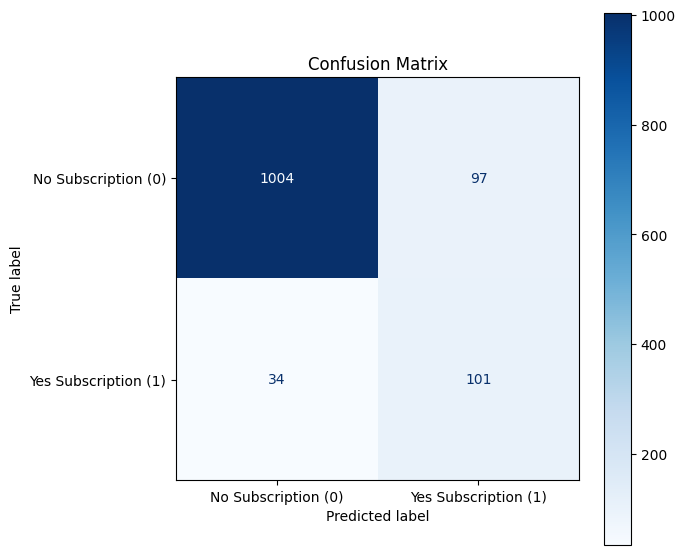

In [88]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_estimator(
    xgb_pipeline,
    X_test,
    y_test,
    display_labels=class_names,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Key performance insights

#### Class 1 (Yes Subscription — our priority)

* **True Positives:** 101
* **False Negatives:** 34

Recall = 101 / (101 + 34) = **0.75**

The model correctly identifies **3 out of 4 actual subscribers**

That’s exactly what you were optimizing for.

#### Class 0 (No Subscription)

* **True Negatives:** 1004
* **False Positives:** 97

Precision drop for class 1 comes from these 97 false alarms

Trade-off: we are “over-predicting interest” slightly

### What this means in plain terms

Our model is now behaving like:

> “I’d rather flag a potentially interested client even if I’m not 100% sure”

That’s exactly what you want in:

* marketing campaigns
* lead generation
* customer outreach

### Trade-off summary

#### Strengths

* High recall for subscribers (0.75)
* Strong separation of non-subscribers
* Good overall stability

#### Cost

* Some wasted outreach (97 false positives)
* Lower precision for positive class (0.51)

### Business interpretation

As this is a marketing use case:

* We are now capturing **most potential customers**
* But contacting some uninterested users

This is usually acceptable because:

> missing a real customer is more expensive than contacting a non-customer

### Final takeaway

This confusion matrix confirms:

> Your model is optimized for **sensitivity (recall) over strict precision**, which aligns with the project goal of improving detection of term deposit subscribers.

## Features Importance

In [89]:
xgb_model = xgb_pipeline.named_steps["model"]
importances = xgb_model.feature_importances_

In [90]:
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [91]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

In [92]:
feature_importance_df.head(15)

,Feature,Importance
2,robust_num__duration,0.128947
0,minmax_num__euribor3m,0.099433
28,nom__poutcome_success,0.083347
4,robust_num__pdays,0.069940
27,nom__poutcome_nonexistent,0.052075
26,nom__contact_telephone,0.046523
5,robust_num__previous,0.043692
7,ord__month,0.042678
16,nom__job_student,0.040326
15,nom__job_services,0.026944


In [93]:
# Plotly bar chart (Top 15)
fig = px.bar(
    feature_importance_df.head(15),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 15 Feature Importances",
)

fig.update_layout(
    yaxis=dict(autorange="reversed"),
    height=600
)

fig.show()

### Top predictive drivers

The model identifies the following variables as the most influential in predicting term deposit subscription:

#### Most important features

* **duration** (0.129)
* **euribor3m** (0.099)
* **poutcome_success** (0.083)
* **pdays** (0.070)
* **poutcome_nonexistent** (0.052)

##### Interpretation

##### 1. Contact behavior dominates prediction

* `duration` is the strongest feature
* This reflects that **longer calls are strongly associated with successful subscription**

> this feature is extremely predictive but may not be available at decision time in real deployment (potential leakage risk depending on use case)

##### 2. Economic conditions matter

* `euribor3m` is the second most important feature

> macroeconomic environment significantly influences client willingness to subscribe to term deposits

This is consistent with financial behavior theory:

* higher rates → more attractive deposits

##### 3. Past campaign outcomes are critical

* `poutcome_success`
* `poutcome_nonexistent`

> previous marketing outcomes strongly influence future conversion probability

This confirms:

* campaign history is a strong behavioral signal
* customer responsiveness is persistent over time

##### 4. Engagement frequency matters

* `campaign`
* `previous`
* `pdays`

> repeated contact has predictive value, but diminishing returns are likely

##### 5. Socio-demographic signals (secondary role)

* job types (student, retired, services)
* marital status
* contact method

> demographic features contribute, but are weaker than behavioral and economic variables

##### Key modeling insight

Your model is clearly driven by:

##### Strong signals

* behavioral features (duration, campaign history)
* macroeconomic indicators

##### Medium signals

* contact strategy variables

##### Weak signals

* demographic attributes

##### Important modeling caution

The high importance of `duration` suggests potential target leakage, as call duration is only known after contact. While it improves predictive performance, it may not be suitable for early-stage customer targeting models.

The feature importance analysis of the optimized XGBoost model reveals that the most influential predictors are related to customer interaction behavior and macroeconomic conditions. In particular, call duration, euribor3m interest rate, and previous campaign outcomes dominate the model’s decision-making process. Behavioral features such as contact history and campaign frequency also play a significant role, while demographic variables contribute comparatively less predictive power. These results suggest that customer responsiveness and economic context are stronger determinants of term deposit subscription than static client attributes.

## ROC Curve

In [94]:
# =========================
# Probabilities (positive class)
# =========================
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# =========================
# ROC-AUC computation
# =========================
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(f"ROC-AUC (XGBoost Optimized): {roc_auc_xgb:.4f}")

ROC-AUC (XGBoost Optimized): 0.9337


In [96]:
# =========================
# ROC computation
# =========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# =========================
# Plotly figure
# =========================
fig = go.Figure()

# ROC curve
fig.add_trace(
    go.Scatter(
        x=fpr,
        y=tpr,
        mode="lines",
        name=f"XGBoost (AUC = {roc_auc_xgb:.3f})",
        line=dict(width=3)
    )
)

# Diagonal baseline
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random Model",
        line=dict(dash="dash")
    )
)

# Layout 
fig.update_layout(
    title="ROC Curve - Optimized XGBoost",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    template="plotly_white",
    width=650,
    height=500
)

fig.update_xaxes(range=[0, 1])
fig.update_yaxes(range=[0, 1])

fig.show()

The optimized XGBoost model achieves a ROC-AUC of 0.9337, indicating a high ability to distinguish between subscribing and non-subscribing clients. This confirms that the model is not only accurate at a fixed threshold but also provides strong probabilistic ranking performance, making it suitable for prioritizing clients in marketing campaigns.

---

# Conclusions and Insights

## Project Objective Summary

The objective of this project was to develop a machine learning model capable of predicting whether a bank client will subscribe to a term deposit, with a particular focus on improving the detection of positive cases (Class 1), given the inherent class imbalance in the dataset.

A complete modeling pipeline was built, including preprocessing, baseline modeling, benchmarking, hyperparameter optimization, and final model evaluation.

## Key Modeling Outcomes

### Final selected model: XGBoost (Optimized)

The optimized **XGBoost classifier** was selected as the final model based on its superior balance between predictive performance and minority class detection.

### Final performance metrics:

* **Accuracy:** 0.8940
* **ROC-AUC:** 0.9337
* **F1 Macro:** 0.7727
* **Class 1 Recall:** 0.7481
* **Class 1 F1-score:** 0.6066

## Model behavior analysis

### Strong class discrimination

The high ROC-AUC (0.9337) indicates that the model has excellent ability to distinguish between subscribers and non-subscribers, making it reliable for ranking and prioritization tasks.

### Improved detection of subscribers (Class 1)

Compared to the baseline Decision Tree model, the optimized XGBoost significantly improves:

* Recall for Class 1: **0.733 → 0.748**
* F1-score for Class 1: **0.533 → 0.606**
* ROC-AUC: **0.818 → 0.933**

This confirms that the optimization process successfully improved the model’s ability to identify potential customers.

### Trade-off: recall vs precision

The model favors recall over precision for Class 1:

* Precision (Class 1): 0.51
* Recall (Class 1): 0.75

This indicates that the model prioritizes capturing as many potential subscribers as possible, at the cost of a higher number of false positives.

### Learning behavior and generalization

The learning curve analysis shows that:

* Training and validation scores converge as dataset size increases
* The model exhibits **low variance and stable generalization**
* No strong evidence of overfitting in the final configuration

## Feature importance insights

The most influential variables driving predictions are:

### Top predictors

* `duration` (call duration)
* `euribor3m` (interest rate environment)
* `poutcome_success` (previous campaign success)
* `pdays` (time since last contact)
* `campaign` (contact frequency)

### Key interpretation

The model is primarily driven by:

* **Behavioral signals** (interaction history, call outcomes)
* **Macroeconomic indicators** (interest rates)
* **Engagement intensity** (campaign contact patterns)

Demographic variables play a secondary role, indicating that customer behavior is a stronger predictor than static attributes.

**Important consideration:**
The strong influence of `duration` may introduce operational bias, as it is only known after contact is initiated. This should be considered when deploying the model in early-stage targeting systems.

## Benchmarking insights

Across multiple models evaluated (Decision Tree, Bagging, SVC, LGBM, XGBoost):

* Ensemble methods consistently outperform single estimators
* XGBoost achieved the best balance between:

  * predictive performance
  * recall of minority class
  * robustness under imbalance

---

# Business insights

## 1. Customer targeting strategy

The model enables prioritization of clients most likely to subscribe, allowing marketing teams to:

* Focus campaigns on high-probability clients
* Reduce wasted outreach
* Improve conversion efficiency

## 2. Economic sensitivity

The importance of `euribor3m` highlights that:

> macroeconomic conditions strongly influence subscription behavior

This suggests that marketing strategies should adapt to interest rate environments.

## 3. Engagement matters more than demographics

The strongest predictors are related to:

* past campaign outcomes
* contact frequency
* interaction behavior

This indicates that **customer responsiveness history is more valuable than demographic segmentation**.

## 4. Expected operational trade-off

The model increases outreach efficiency but also introduces:

* more false positives (lower precision)
* higher contact volume

However, this is acceptable in marketing contexts where:

> missing a potential subscriber is more costly than contacting a non-interested client.

---

# Business recommendations

## 1. Deploy XGBoost as a scoring model

Use predicted probabilities to rank clients rather than binary classification.

## 2. Optimize decision threshold

The current threshold (0.5) can be adjusted to:

* increase recall (aggressive targeting)
* or improve precision (cost-sensitive campaigns)

## 3. Focus on high-impact features

Marketing strategies should prioritize:

* improving call effectiveness (duration proxy)
* leveraging past campaign success patterns
* timing campaigns with favorable economic conditions

## 4. Implement campaign segmentation

Segment customers based on predicted probability:

* High probability → direct outreach
* Medium probability → nurturing campaigns
* Low probability → excluded or low-cost channels

## 5. Monitor model drift

Because economic variables strongly influence predictions, the model should be periodically retrained to reflect:

* interest rate changes
* macroeconomic shifts
* campaign behavior evolution

---

# Final conclusion

The optimized XGBoost model provides a strong and well-balanced solution for predicting term deposit subscriptions. It significantly improves detection of potential customers compared to baseline models, while maintaining robust overall performance and strong generalization capability.

The model is suitable for deployment in a marketing decision-support system, where its probability outputs can be used to optimize customer targeting and improve campaign efficiency.

---

# Appendix

## References

- [Bank Marketing Dataset from the UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)
- Machine Learning notebooks from the bootcamp repository (*sonda2026* branch)
- Machine Learning notebooks from the shared Assistanship Google Drive folder
- [Pandas Documentation](https://pandas.pydata.org/docs/user_guide/index.html?utm_source=chatgpt.com)
- [Plotly Documentation](https://plotly.com/python/?utm_source=chatgpt.com)

## Acknowledgements

I would like to thank my instructors for their guidance, continuous support, and encouragement throughout the development of this project.

I also acknowledge the use of AI-assisted tools to support debugging, code review, documentation, and the exploration of machine learning concepts during the analysis process. All modeling decisions, interpretations, and conclusions presented in this work were made independently and remain my own responsibility.

---

### Tools and Technologies

- Python
- Pandas
- NumPy
- SciPy
- Plotly
- MatPlotLib
- SkLearn
- XGBoost
- LightGBM
- JobLib
- LazyPredict
- Optuna
- Jupyter Notebook